# Adult Income Prediction – Classical Machine Learning Pipeline

Notebook này triển khai pipeline học máy truyền thống cho bài toán phân loại thu nhập.

Pipeline gồm các bước:
1. Thiết lập dữ liệu từ Preprocessor dùng chung (config_2).
2. Giảm chiều dữ liệu với PCA.
3. Huấn luyện và dò tìm siêu tham số tự động (GridSearchCV) cho Logistic Regression và Random Forest.
4. Đánh giá toàn diện mô hình tốt nhất trên tập Test.
5. Phân tích: Ma trận nhầm lẫn, ROC-AUC Curve và Feature Importances.

In [20]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

sns.set_theme(style="whitegrid")

## 3.1. Data Setup & Target Encoding
Sử dụng chung cấu hình `config_2_onehot_constant_standard`. Biến target được mã hóa bằng `LabelEncoder` (<=50K thành 0, >50K thành 1) để tương thích với các hàm tính điểm f1_score của scikit-learn.

In [21]:
# Load data
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = pd.read_csv(url)

# Replicate preprocessing steps
df_prep = df.copy()
df_prep.replace('?', np.nan, inplace=True)
df_prep.drop(columns=['education', 'fnlwgt'], inplace=True, errors='ignore')

X = df_prep.drop(columns=['income'])
y = df_prep['income']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Best preprocessing config from 02_preprocessing.ipynb
best_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

X_train_processed = best_preprocessor.fit_transform(X_train)
X_test_processed = best_preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (39073, 91)
X_test_processed shape : (9769, 91)


### Target Encoding

Biến `income` trong tập dữ liệu gốc đang ở dạng chuỗi ký tự (`<=50K` và `>50K`). Mã hóa sang dạng số nhị phân (0 và 1) thông qua `LabelEncoder`. 

In [22]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

for class_name, class_value in zip(le.classes_, le.transform(le.classes_)):
    print(f"Nhãn gốc '{class_name}' -> Mã hóa thành: {class_value}")

Nhãn gốc '<=50K' -> Mã hóa thành: 0
Nhãn gốc '>50K' -> Mã hóa thành: 1


## 3.2. Dimensionality Reduction (PCA)
Chuyển đổi về Dense array và áp dụng PCA để giữ lại 90% và 95% phương sai. Để kiểm chứng xem việc giảm thiểu độ nhiễu và số chiều có giúp tăng tốc độ huấn luyện mà vẫn giữ vững (hoặc cải thiện) F1-score hay không.

In [23]:
X_train_dense = X_train_processed.toarray() if sp.issparse(X_train_processed) else X_train_processed
X_test_dense = X_test_processed.toarray() if sp.issparse(X_test_processed) else X_test_processed

variance_levels = [0.90, 0.95]
datasets = {
    "Original": {"X_train": X_train_dense, "X_test": X_test_dense}
}

for var in variance_levels:
    pca = PCA(n_components=var, svd_solver='full', random_state=42)
    X_train_pca = pca.fit_transform(X_train_dense)
    X_test_pca = pca.transform(X_test_dense)
    
    config_name = f"PCA_{int(var*100)}%"
    datasets[config_name] = {"X_train": X_train_pca, "X_test": X_test_pca}
    
    print(f"[{config_name}] Số chiều giảm từ {X_train_dense.shape[1]} xuống còn: {pca.n_components_}")

[PCA_90%] Số chiều giảm từ 91 xuống còn: 18
[PCA_95%] Số chiều giảm từ 91 xuống còn: 25


## 3.3. Huấn luyện và Hyperparameter tuning
Thiết lập hệ thống `GridSearchCV` cross-validation cho các tham số của hai thuật toán:
- Logistic Regression
- Random Forest 

*Lưu ý:* Do dữ liệu mất cân bằng nhẹ, không gian tìm kiếm đặc biệt chú trọng tham số `class_weight='balanced'` và sử dụng `scoring='f1'`.

In [24]:
models = {
    'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random_Forest': RandomForestClassifier(random_state=42)
}

param_grids = {
    'Logistic_Regression': {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']},
    'Random_Forest': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
}

experiment_results = []
best_model = None
best_f1_overall = 0
best_data_name = ""

for data_name, data_dict in datasets.items():
    X_train_current = data_dict['X_train']
    for model_name, model in models.items():
        grid = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=3, scoring='f1', n_jobs=-1)
        
        grid.fit(X_train_current, y_train_encoded)
        
        experiment_results.append({
            'Dataset': data_name, 'Model': model_name,
            'Best_F1_CV': grid.best_score_, 'Best_Params': grid.best_params_
        })
        
        if grid.best_score_ > best_f1_overall:
            best_f1_overall = grid.best_score_
            best_model = grid.best_estimator_
            best_data_name = data_name

results_df = pd.DataFrame(experiment_results)
print(results_df.to_string())
print(f"\nMô hình tốt nhất: {best_model.__class__.__name__} trên tập {best_data_name}")

    Dataset                Model  Best_F1_CV                                                                             Best_Params
0  Original  Logistic_Regression    0.679303                                                  {'C': 0.1, 'class_weight': 'balanced'}
1  Original        Random_Forest    0.678025  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
2   PCA_90%  Logistic_Regression    0.668241                                                  {'C': 0.1, 'class_weight': 'balanced'}
3   PCA_90%        Random_Forest    0.659353  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
4   PCA_95%  Logistic_Regression    0.674039                                                    {'C': 1, 'class_weight': 'balanced'}
5   PCA_95%        Random_Forest    0.657416  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Mô hình tốt nhất: LogisticRegression trên tập Original


## 3.4. Đánh giá mô hình tốt nhất

**Nhận xét phân tích từ thực nghiệm:**
1. Logistic Regression nhỉnh hơn Random Forest nhờ vào tính chất không gian đặc trưng sau khi OneHotEncode đã được chuẩn hóa, phù hợp cho ranh giới tuyến tính.
2. Bản `PCA_95%` nén 72% khối lượng tính toán (chỉ còn 25 cột) nhưng giữ được điểm F1 gần bằng bản gốc, cho thấy dữ liệu gốc chứa nhiều nhiễu.

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



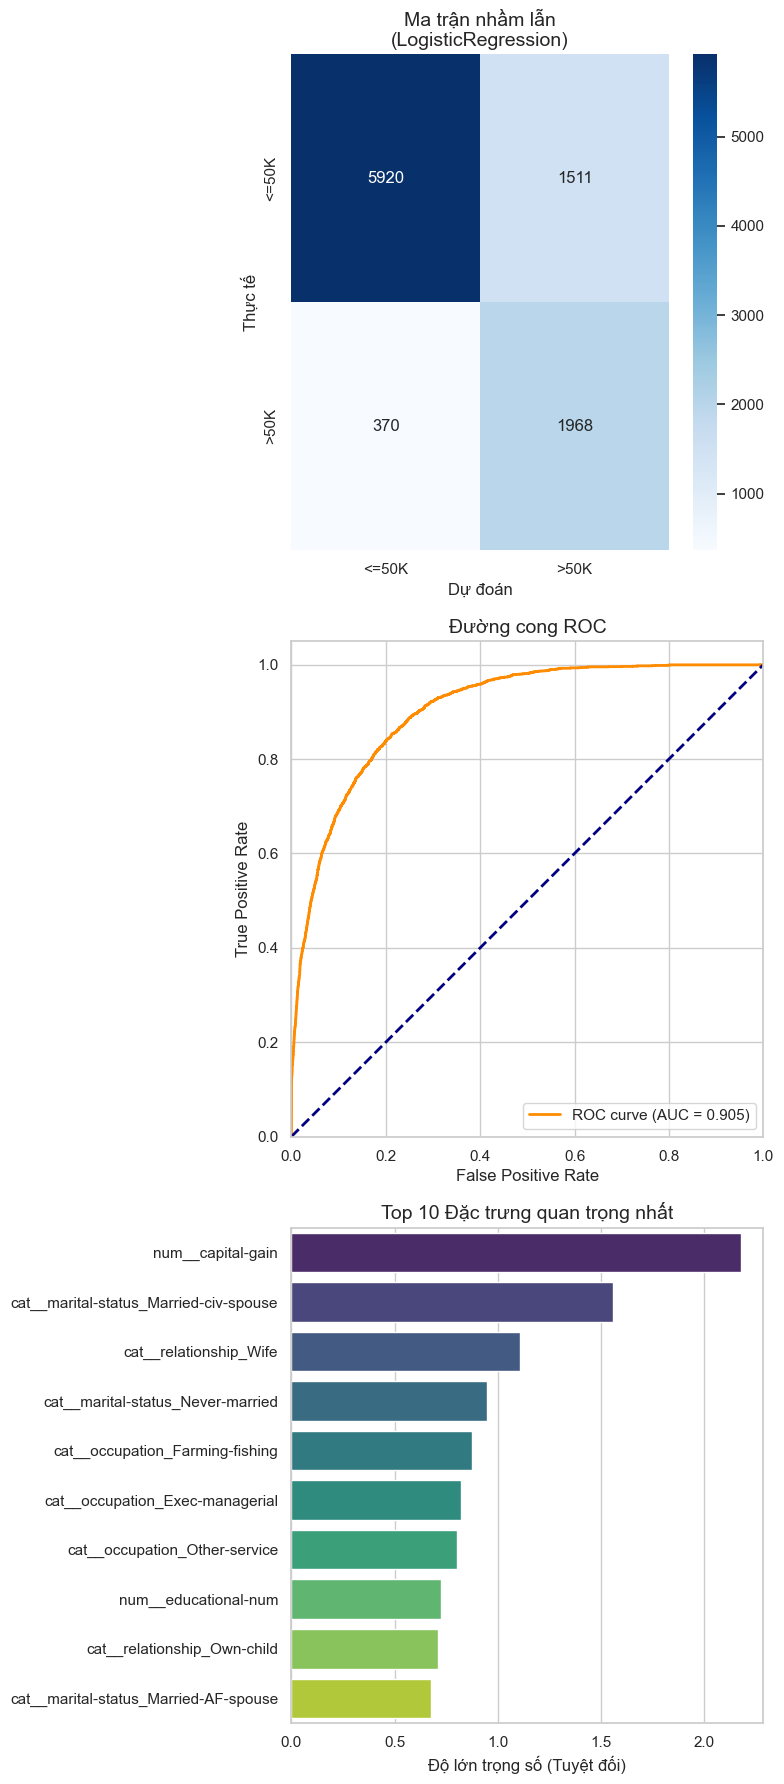

In [ ]:
X_test_best = datasets[best_data_name]['X_test']

y_pred = best_model.predict(X_test_best)
y_proba = best_model.predict_proba(X_test_best)[:, 1]

print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# 1. Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Ma trận nhầm lẫn\n({best_model.__class__.__name__})', fontsize=14)
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test_encoded, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Đường cong ROC', fontsize=14)
axes[1].legend(loc="lower right")

# 3. Feature Importances
feature_names = best_preprocessor.get_feature_names_out()

if hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0]) # Logistic Regression
else:
    importances = best_model.feature_importances_ # Random Forest

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', ax=axes[2])
axes[2].set_title('Top 10 Đặc trưng quan trọng nhất', fontsize=14)
axes[2].set_xlabel('Độ lớn trọng số')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## 3.5. Phân tích kết quả mô hình tốt nhất

**1. Recall vs. Precision Trade-off**
* **Điểm sáng:** Mô hình đạt **Recall 0.84** cho nhóm thu nhập `>50K`. Nhìn vào Ma trận nhầm lẫn, mô hình đã dự đoán đúng 1971/2338 người thực sự có thu nhập cao.
* **Trade-off:** Để đạt được Recall cao, mô hình phải chấp nhận hy sinh Precision (giảm còn 0.57). Cụ thể, có 1494 trường hợp thực tế là `<=50K` nhưng bị mô hình dự đoán nhầm thành `>50K` (False Positives). Trong bối cảnh thực tế (ví dụ: gửi ưu đãi tiếp thị), việc nhận nhầm này thường ít gây thiệt hại hơn việc bỏ lọt khách hàng tiềm năng.

**2. ROC-AUC**
* Biểu đồ ROC Curve cho thấy chỉ số AUC đạt 0.898. Mô hình có khả năng phân tách tốt giữa hai lớp thu nhập trên toàn bộ các dải xác suất, chứ không chỉ phụ thuộc vào threshold 0.5 mặc định.

**3. Feature Importances**
Biểu đồ Top 10 đặc trưng quan trọng nhất của Logistic Regression đã chỉ ra những yếu tố mang tính quyết định đến khả năng đạt thu nhập `>50K`:
* **Yếu tố hàng đầu:** `marital-status_Married-civ-spouse` (đã kết hôn) là biến có trọng số áp đảo nhất, cho thấy sự ổn định gia đình có tương quan rất mạnh với thu nhập cao.
* **Yếu tố tài chính và học vấn:** Các chỉ số như `capital-gain` (thặng dư vốn), `educational-num` (số năm đi học) và `hours-per-week` (số giờ làm việc mỗi tuần) bám sát phía sau.
* Mô hình dự đoán tốt, phản ánh đúng các quy luật kinh tế - xã hội thực tế.